In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sheryanalysis as sh
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


<Axes: xlabel='reading score', ylabel='Count'>

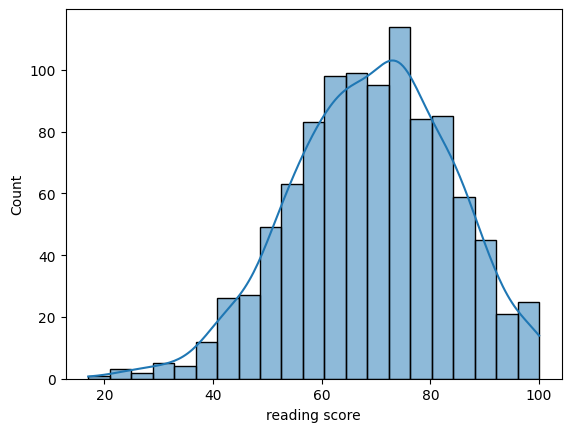

In [6]:
sns.histplot( df['reading score'] ,  kde=True )

<Axes: xlabel='writing score', ylabel='Count'>

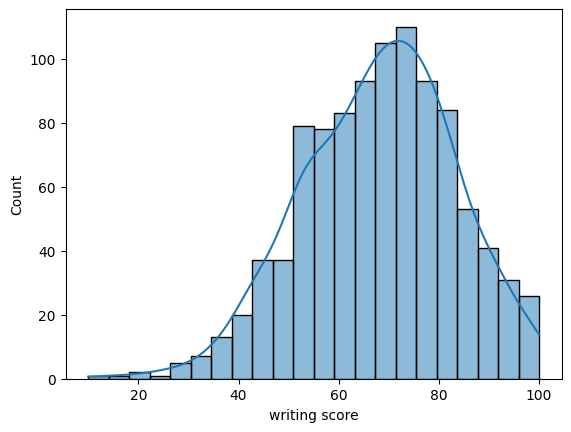

In [7]:
sns.histplot( df['writing score'] ,  kde=True )

<Axes: xlabel='reading score', ylabel='math score'>

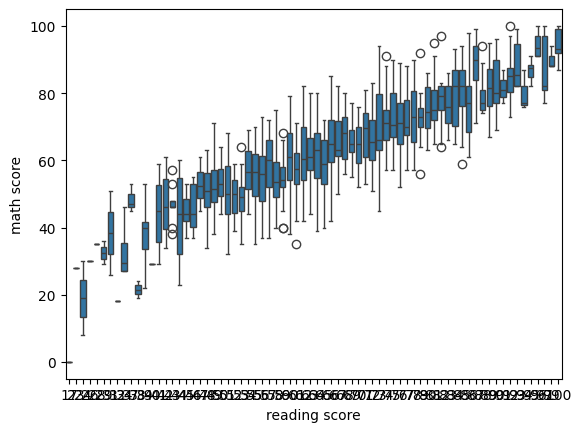

In [8]:
sns.boxplot( data=df , x='reading score' , y='math score' )

<Axes: xlabel='writing score', ylabel='math score'>

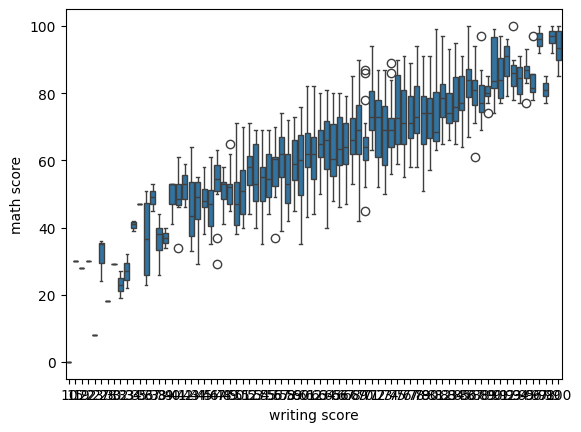

In [9]:
sns.boxplot( data=df , x='writing score' , y='math score' )


<Axes: xlabel='gender', ylabel='count'>

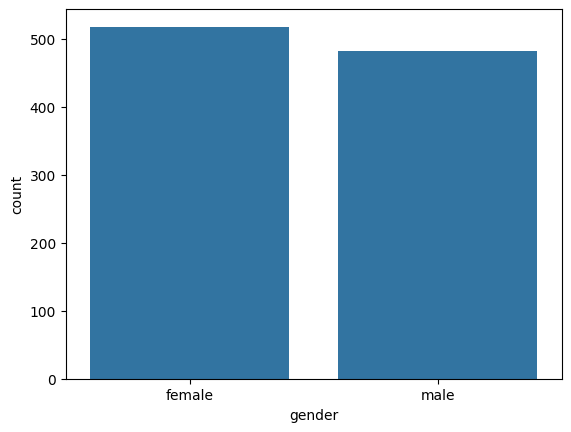

In [10]:
sns.countplot(x = df['gender'])

<Axes: xlabel='race/ethnicity', ylabel='count'>

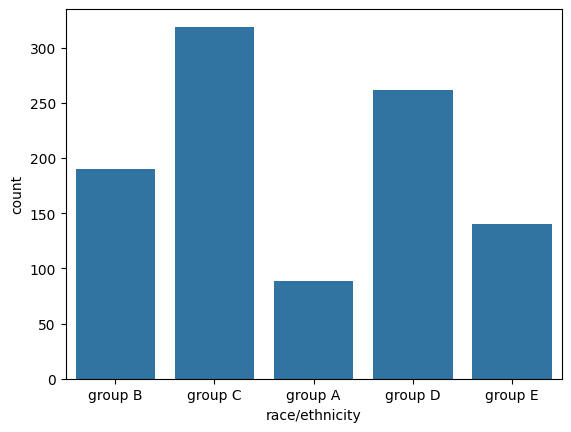

In [11]:
sns.countplot(x = df['race/ethnicity'])

<Axes: xlabel='parental level of education', ylabel='count'>

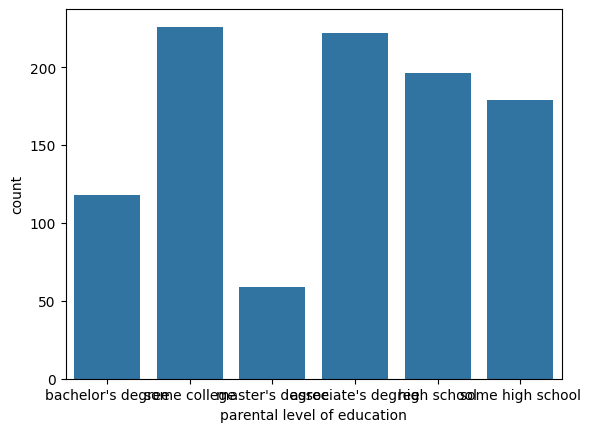

In [12]:
sns.countplot(x = df['parental level of education'])

In [13]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


<Axes: >

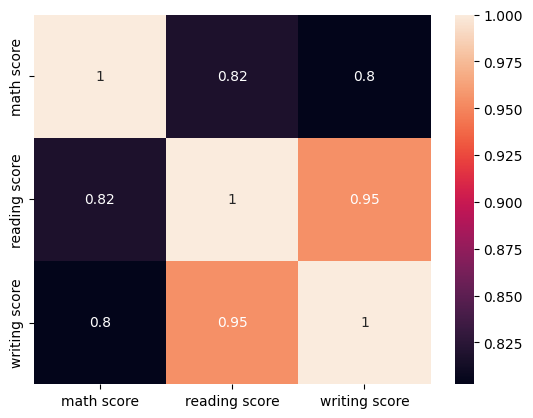

In [14]:
sns.heatmap( df.corr(numeric_only=True) , annot=True )

In [15]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [16]:
df_encoded = pd.get_dummies( df , drop_first=True)

In [17]:
df_encoded

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,88,99,95,False,False,False,False,True,False,False,True,False,False,True,False
996,62,55,55,True,False,True,False,False,False,True,False,False,False,False,True
997,59,71,65,False,False,True,False,False,False,True,False,False,False,False,False
998,68,78,77,False,False,False,True,False,False,False,False,True,False,True,False


In [18]:
df_encoded = df_encoded.astype(int)

In [19]:
df_encoded.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,0,1,0,0,0,1,0,0,0,0,1,1
1,69,90,88,0,0,1,0,0,0,0,0,1,0,1,0
2,90,95,93,0,1,0,0,0,0,0,1,0,0,1,1
3,47,57,44,1,0,0,0,0,0,0,0,0,0,0,1
4,76,78,75,1,0,1,0,0,0,0,0,1,0,1,1


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols = ['reading score' , 'writing score']
df_encoded[ cols ] = scaler.fit_transform(df_encoded[cols])

In [21]:
df_encoded

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,0.193999,0.391492,0,1,0,0,0,1,0,0,0,0,1,1
1,69,1.427476,1.313269,0,0,1,0,0,0,0,0,1,0,1,0
2,90,1.770109,1.642475,0,1,0,0,0,0,0,1,0,0,1,1
3,47,-0.833899,-1.583744,1,0,0,0,0,0,0,0,0,0,0,1
4,76,0.605158,0.457333,1,0,1,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,88,2.044215,1.774157,0,0,0,0,1,0,0,1,0,0,1,0
996,62,-0.970952,-0.859491,1,0,1,0,0,0,1,0,0,0,0,1
997,59,0.125472,-0.201079,0,0,1,0,0,0,1,0,0,0,0,0
998,68,0.605158,0.589015,0,0,0,1,0,0,0,0,1,0,1,0


In [ ]:
from scipy.stats import chi2_contingency
target = 'math score'
alpha = 0.5
results ={}

for col in df_encoded.columns:
    if col != target:
        table = pd.crosstab(df_encoded[col], df_encoded[target])

        chi2_stat, p_value, dof, expected = chi2_contingency(table)

        if p_value < alpha:
            decision = "Reject H0 (keep Feature)"
        else:
            decision = "Accept H0 (Drop Feature)"

        results[col] = {
            "chi2_stat": chi2_stat,
            "p_value": p_value,
            "decision": decision
        }

chi2_df = pd.DataFrame( results ).T
chi2_df.sort_values( by='p_value' )
chi2_df

,chi2_stat,p_value,decision
reading score,13446.995134,0.0,Reject H0 (keep Feature)
writing score,14066.859028,0.0,Reject H0 (keep Feature)
gender_male,93.256767,0.1475,Reject H0 (keep Feature)
race/ethnicity_group B,85.484981,0.316846,Reject H0 (keep Feature)
race/ethnicity_group C,83.101561,0.384123,Reject H0 (keep Feature)
race/ethnicity_group D,76.961092,0.575523,Accept H0 (Drop Feature)
race/ethnicity_group E,134.339966,0.000137,Reject H0 (keep Feature)
parental level of education_bachelor's degree,69.406243,0.795111,Accept H0 (Drop Feature)
parental level of education_high school,100.283404,0.062171,Reject H0 (keep Feature)
parental level of education_master's degree,66.501668,0.860005,Accept H0 (Drop Feature)


In [23]:
cols = ['math score'  , 'reading score' , 'writing score' , 'gender_male' ,'race/ethnicity_group B'	 , 'race/ethnicity_group C' , 'race/ethnicity_group E' , 'parental level of education_high school' , 'parental level of education_some college' ,'parental level of education_some high school' , 'lunch_standard'	, 'test preparation course_none']
df_final = df_encoded[ cols ]

In [24]:
df_final.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group E,parental level of education_high school,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,0.193999,0.391492,0,1,0,0,0,0,0,1,1
1,69,1.427476,1.313269,0,0,1,0,0,1,0,1,0
2,90,1.770109,1.642475,0,1,0,0,0,0,0,1,1
3,47,-0.833899,-1.583744,1,0,0,0,0,0,0,0,1
4,76,0.605158,0.457333,1,0,1,0,0,1,0,1,1


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X = df_final.drop('math score' , axis=1)
y = df_final['math score']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

model.fit(X_train , y_train)

y_pred = model.predict( X_test )

In [30]:
from sklearn.metrics import  r2_score

In [31]:
r2 = r2_score( y_test , y_pred )
print(r2)

0.8796064975581095


In [32]:
n = X_test.shape[0]

P = X_test.shape[1]

adj_r2 = 1 - (  (1 - r2 ) * ( n - 1 )  ) / ( n - P - 1 )

adj_r2

0.872562196883318